In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Trova tutti i TIF nelle cartelle
tif_files = []
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".tif"):
            tif_files.append(os.path.join(root, f))

print(f"Trovati {len(tif_files)} file TIF")
for f in tif_files[:10]:
    print(f)

Trovati 3 file TIF
./Jeju/Dem10m/Raster Jeju 5k.tif
./ElHierro/DEM/dem5m/Hierro.tif
./Etna/DEM2m/DEM 2 m Etna-001.tif


In [2]:
with rasterio.open(tif_files[0]) as src:
    data_raw = src.read(1)  # completamente raw
    print(f"dtype: {data_raw.dtype}")
    print(f"min raw: {data_raw.min()}")
    print(f"max raw: {data_raw.max()}")
    
    if data_raw.dtype in [np.float32, np.float64]:
        nan_count = np.isnan(data_raw).sum()
        print(f"Pixel NaN: {nan_count} / {data_raw.size}")
        non_nan = data_raw[~np.isnan(data_raw)]
        if len(non_nan) > 0:
            print(f"Min valido: {non_nan.min():.1f}m")
            print(f"Max valido: {non_nan.max():.1f}m")
        else:
            print("Tutti i pixel sono NaN!")

dtype: float64
min raw: nan
max raw: nan
Pixel NaN: 9121083 / 33869004
Min valido: 0.0m
Max valido: 1945.0m



--- ./Jeju/Dem10m/Raster Jeju 5k.tif ---
Dimensioni: 7761 x 4364 pixel
Risoluzione: (10.0002383713439, 10.000139780018408)
Elevazione min: 0.0m, max: 1945.0m
Pixel validi: 24747921 / 33869004


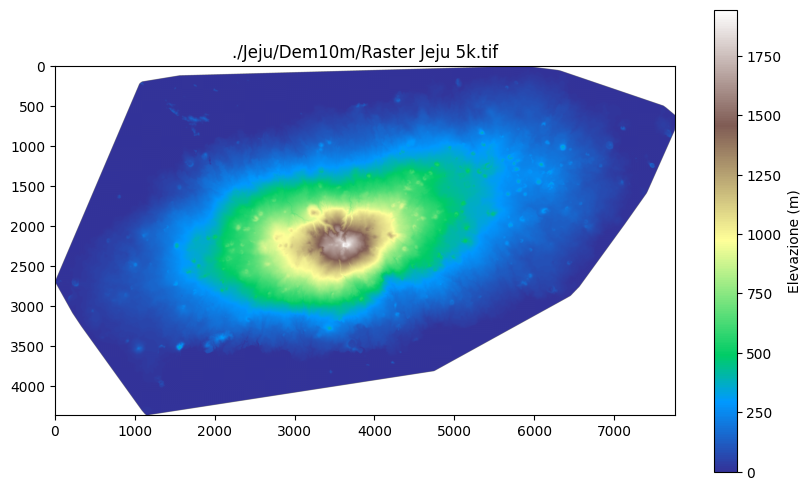


--- ./ElHierro/DEM/dem5m/Hierro.tif ---
Dimensioni: 5681 x 5081 pixel
Risoluzione: (5.0, 5.0)
Elevazione min: -0.0m, max: 1499.8m
Pixel validi: 17323787 / 28865161


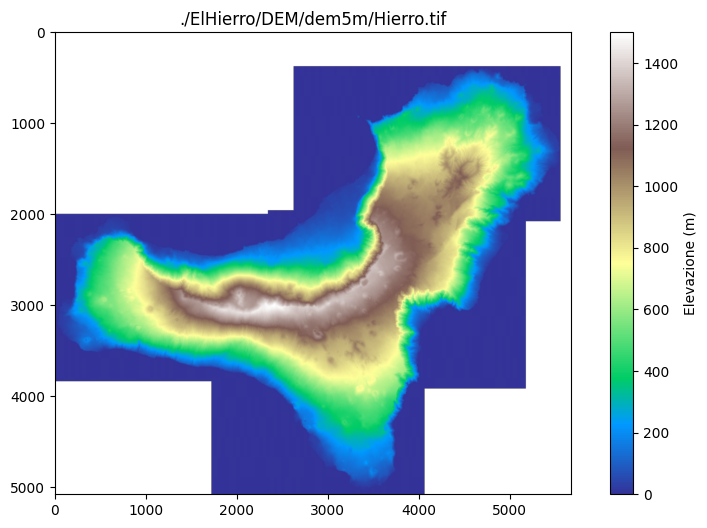


--- ./Etna/DEM2m/DEM 2 m Etna-001.tif ---
Dimensioni: 25717 x 27756 pixel
Risoluzione: (2.0, 2.0)
Elevazione min: -3.3m, max: 3324.1m
Pixel validi: 536013646 / 713801052


In [ ]:
for tif_path in tif_files:
    with rasterio.open(tif_path) as src:
        print(f"\n--- {tif_path} ---")
        print(f"Dimensioni: {src.width} x {src.height} pixel")
        print(f"Risoluzione: {src.res}")
        
        data = src.read(1)  # raw, niente masked
        data = data.astype(np.float64)
        data[data < -9000] = np.nan  # cattura sia -9999 che -3.4e38
        valid_min = np.nanmin(data)
        valid_max = np.nanmax(data)
        print(f"Elevazione min: {valid_min:.1f}m, max: {valid_max:.1f}m")
        print(f"Pixel validi: {(~np.isnan(data)).sum()} / {data.size}")
        
        plt.figure(figsize=(10, 6))
        plt.imshow(data, cmap='terrain', vmin=valid_min, vmax=valid_max)
        plt.colorbar(label='Elevazione (m)')
        plt.title(tif_path)
        plt.show()